# 📊 Modelos de Regresión con Pipelines

Cinco clases que simplifican el flujo completo de modelado:
split → pipeline → fit → métricas en un solo `.fit(X, y)`.

| Clase | Archivo | Algoritmo |
|---|---|---|
| `StepwiseLinearRegression` | `stepwise_regression.py` | OLS + Stepwise por AIC |
| `RegularizedRegression` | `regularized_regression.py` | Lasso / Ridge + CV para alpha |
| `RandomForestRegression` | `random_forest_regression.py` | Random Forest |
| `XGBoostRegression` | `xgboost_regression.py` | XGBoost |
| `CatBoostRegression` | `catboost_regression.py` | CatBoost |

**Dataset:** `make_regression` de scikit-learn (500 muestras, 10 features, 7 informativas).

## 0. Dependencias

In [ ]:
# Solo si es necesario
# !pip install scikit-learn xgboost catboost pandas numpy matplotlib seaborn

## 1. Importaciones

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import make_regression

## Importamos los modelos PROPIOS que hemos implementado en esta monitoría ##

from stepwise_regression      import StepwiseLinearRegression
from regularized_regression   import RegularizedRegression
from random_forest_regression import RandomForestRegression
from xgboost_regression       import XGBoostRegression
from catboost_regression      import CatBoostRegression

print('✅ Listo')

✅ Listo


## 2. Dataset

In [3]:
df = pd.read_csv('weatherHistory.csv')
df

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
...,...,...,...,...,...,...,...,...,...,...,...,...
96448,2016-09-09 19:00:00.000 +0200,Partly Cloudy,rain,26.016667,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,Partly cloudy starting in the morning.
96449,2016-09-09 20:00:00.000 +0200,Partly Cloudy,rain,24.583333,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,Partly cloudy starting in the morning.
96450,2016-09-09 21:00:00.000 +0200,Partly Cloudy,rain,22.038889,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,Partly cloudy starting in the morning.
96451,2016-09-09 22:00:00.000 +0200,Partly Cloudy,rain,21.522222,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,Partly cloudy starting in the morning.


In [ ]:

X_df = pd.DataFrame(X, columns=['Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)', 'Pressure (millibars)' ])
y_s  = pd.Series()

print(f'X: {X_df.shape}   y: {y_s.shape}')
X_df.head(3)

X: (500, 10)   y: (500,)


,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9
0,-2.132596,2.307916,-1.315816,-0.181449,-0.106337,-0.158154,0.281009,1.012637,-1.435910,3.243093
1,-1.106526,-0.024125,1.126565,0.198085,-0.144360,0.059218,-0.268889,2.573360,1.848956,0.013929
2,0.184551,1.208366,2.558199,1.024063,0.592527,2.006093,-0.564248,1.542110,-0.551858,2.061504


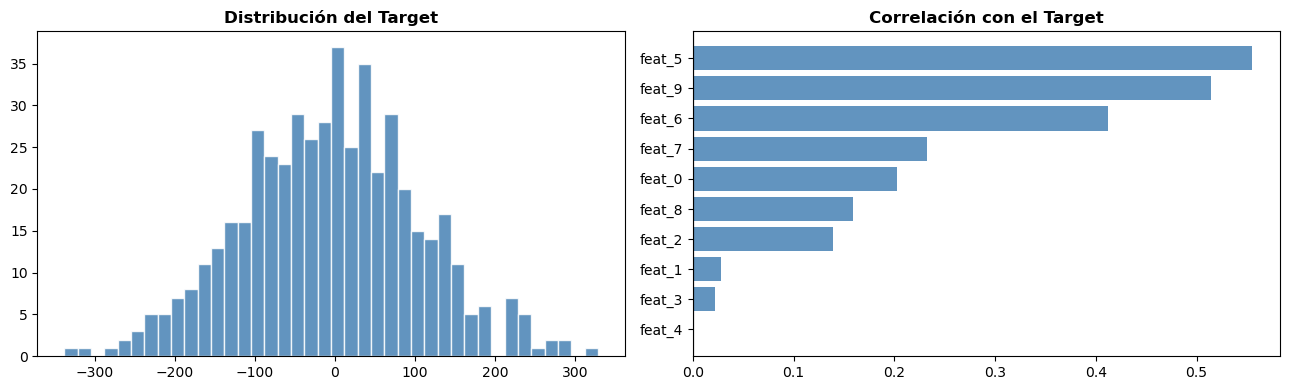

In [35]:
# Distribución del target y correlaciones
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(y_s, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribución del Target', fontweight='bold')

corr = X_df.assign(target=y_s).corr()
target_corr = corr['target'].drop('target').sort_values()
colors = ['tomato' if v < 0 else 'steelblue' for v in target_corr]
axes[1].barh(target_corr.index, target_corr.values, color=colors, alpha=0.85)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Correlación con el Target', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 3. Modelo 1 — Stepwise Linear Regression (AIC)

Selecciona automáticamente las variables que minimizan el AIC mediante pasos Forward y Backward.

In [36]:
# ── Uso mínimo ────────────────────────────────────────────────────────
sw = StepwiseLinearRegression().fit(X_df, y_s)

Stepwise Both por AIC ...
  Paso  0 | AIC nulo: 3756.3467
  Paso  1 | + feat_5                 | AIC = 3625.2208
  Paso  2 | + feat_9                 | AIC = 3397.4588
  Paso  3 | + feat_6                 | AIC = 3122.0454
  Paso  4 | + feat_0                 | AIC = 3013.5437
  Paso  5 | + feat_7                 | AIC = 2822.6684
  Paso  6 | + feat_2                 | AIC = 2618.9173
  Paso  7 | + feat_8                 | AIC = 2404.8370
  Paso  8 | + feat_3                 | AIC = 2401.9586
  → Convergencia. AIC final = 2401.9586
  Seleccionadas (8): ['feat_5', 'feat_9', 'feat_6', 'feat_0', 'feat_7', 'feat_2', 'feat_8', 'feat_3']


In [37]:
sw.print_metrics()


  Stepwise AIC (both)  |  8 var(s): ['feat_5', 'feat_9', 'feat_6', 'feat_0', 'feat_7', 'feat_2', 'feat_8', 'feat_3']
  R²      : 0.966989
  MSE     : 427.467129
  RMSE    : 20.675278
  MAE     : 16.08975
  AIC_final: 2401.9586


In [38]:
# Historial paso a paso del AIC
sw.print_aic_trace()


  Historial AIC — Stepwise Both
  Paso  Acción      Variable                       AIC
--------------------------------------------------------------
     0  inicio      —                        3756.3467
     1  añadir      feat_5                   3625.2208
     2  añadir      feat_9                   3397.4588
     3  añadir      feat_6                   3122.0454
     4  añadir      feat_0                   3013.5437
     5  añadir      feat_7                   2822.6684
     6  añadir      feat_2                   2618.9173
     7  añadir      feat_8                   2404.8370
     8  añadir      feat_3                   2401.9586


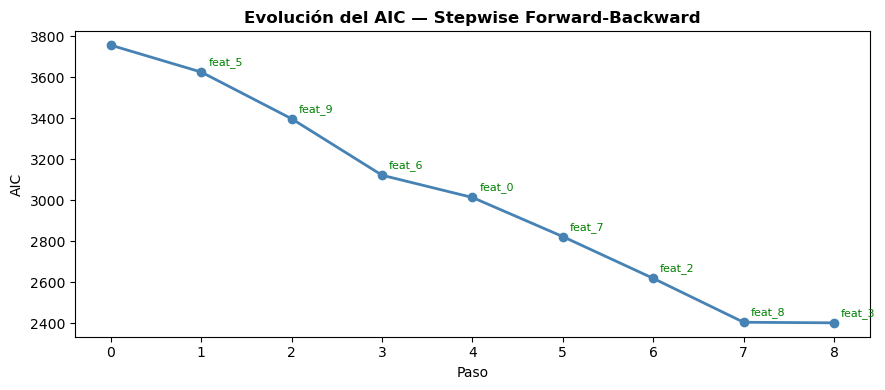

In [39]:
# Evolución gráfica del AIC
trace = sw.get_aic_trace()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(trace['Paso'], trace['AIC'], marker='o', color='steelblue', lw=2)
for _, row in trace.iterrows():
    if row['Acción'] != 'inicio':
        color = 'green' if row['Acción'] == 'añadir' else 'red'
        ax.annotate(row['Variable'], (row['Paso'], row['AIC']),
                    textcoords='offset points', xytext=(5, 5),
                    fontsize=8, color=color)
ax.set_title('Evolución del AIC — Stepwise Forward-Backward', fontweight='bold')
ax.set_xlabel('Paso')
ax.set_ylabel('AIC')
plt.tight_layout()
plt.show()

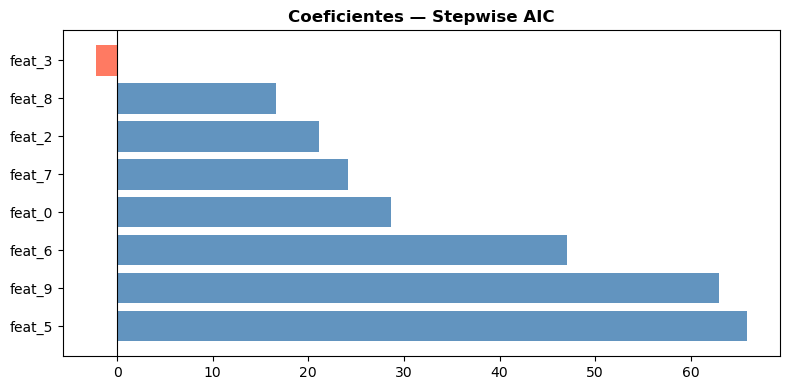

In [40]:
# Coeficientes del modelo final
coef = sw.get_coefficients()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['tomato' if v < 0 else 'steelblue' for v in coef['Coeficiente']]
ax.barh(coef['Feature'], coef['Coeficiente'], color=colors, alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Coeficientes — Stepwise AIC', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Modelo 2 — Regularized Regression (Lasso + Ridge)

Ajusta ambos modelos en una sola llamada. El alpha óptimo se busca con validación cruzada.

In [41]:
# ── Uso mínimo ────────────────────────────────────────────────────────
reg = RegularizedRegression().fit(X_df, y_s)

Ajustando Lasso ...
  Mejor alpha (Lasso): 0.247708
Ajustando Ridge ...
  Mejor alpha (Ridge): 0.000100
Ajustando Elasticnet ...
  Mejor alpha (ElasticNet)   : 0.268270
  Mejor l1_ratio (ElasticNet): 1.0000  (→ más Lasso)


In [42]:
reg.print_metrics()


  Lasso  |  alpha = 0.247708
  R²      : 0.96759
  MSE     : 419.692095
  RMSE    : 20.486388
  MAE     : 16.028399

  Ridge  |  alpha = 0.000100
  R²      : 0.967283
  MSE     : 423.660864
  RMSE    : 20.583024
  MAE     : 16.028879

  Elasticnet  |  alpha = 0.268270  |  l1_ratio = 1.000000
  R²      : 0.96761
  MSE     : 419.426303
  RMSE    : 20.4799
  MAE     : 16.030351


In [43]:
# Tabla comparativa Lasso vs Ridge
reg.compare()

,R²,MSE,RMSE,MAE,alpha,l1_ratio
Modelo,,,,,,
Lasso,0.967590,419.692095,20.486388,16.028399,0.247708,NaN
Ridge,0.967283,423.660864,20.583024,16.028879,0.000100,NaN
Elasticnet,0.967610,419.426303,20.479900,16.030351,0.268270,1.0


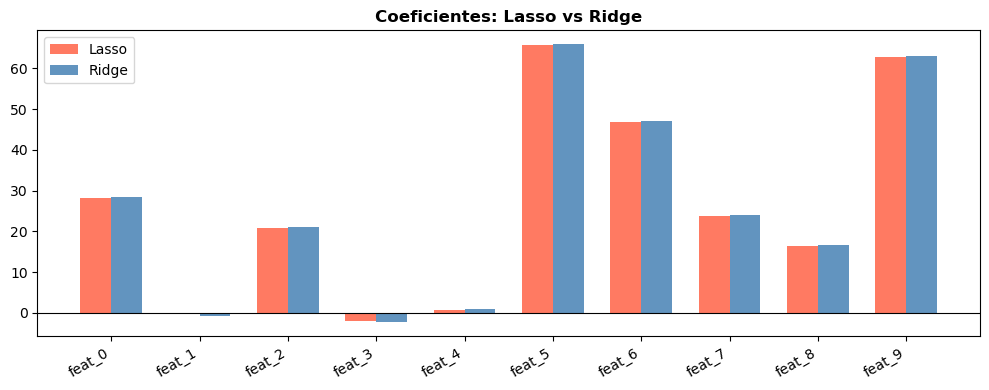

In [44]:
# Coeficientes Lasso vs Ridge
coef_reg = reg.get_coefficients()

x_pos = np.arange(len(coef_reg))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x_pos - w/2, coef_reg['Coef_Lasso'], w, label='Lasso', color='tomato',    alpha=0.85)
ax.bar(x_pos + w/2, coef_reg['Coef_Ridge'], w, label='Ridge', color='steelblue', alpha=0.85)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(coef_reg['Feature'], rotation=30, ha='right')
ax.set_title('Coeficientes: Lasso vs Ridge', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Modelo 3 — Random Forest Regression

In [45]:
# ── Uso mínimo ────────────────────────────────────────────────────────
rf = RandomForestRegression().fit(X_df, y_s)

Ajustando Random Forest ...


In [46]:
rf.print_metrics()


  Random Forest Regression
  R²      : 0.788769
  MSE     : 2735.304199
  RMSE    : 52.300136
  MAE     : 41.242389


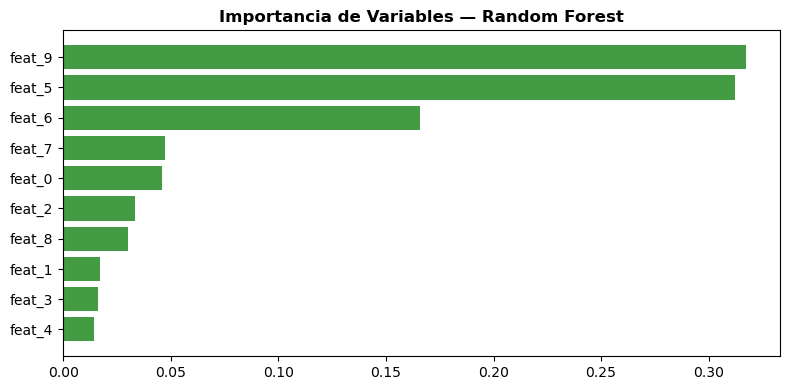

In [47]:
# Importancia de variables
fi_rf = rf.get_feature_importance()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(fi_rf['Feature'], fi_rf['Importancia'], color='forestgreen', alpha=0.85)
ax.set_title('Importancia de Variables — Random Forest', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [48]:
# Con tuning automático (aumenta n_iter para mejor búsqueda)
rf_tuned = RandomForestRegression(tune=True, n_iter=10, cv=3).fit(X_df, y_s)
rf_tuned.print_metrics()

Buscando hiperparámetros (random) ...
  Mejores parámetros: {'regressor__n_estimators': 300, 'regressor__min_samples_split': 2, 'regressor__min_samples_leaf': 1, 'regressor__max_features': 0.5, 'regressor__max_depth': None}

  Random Forest Regression
  Params: {'regressor__n_estimators': 300, 'regressor__min_samples_split': 2, 'regressor__min_samples_leaf': 1, 'regressor__max_features': 0.5, 'regressor__max_depth': None}
  R²      : 0.791737
  MSE     : 2696.866782
  RMSE    : 51.931366
  MAE     : 39.071079


---
## 6. Modelo 4 — XGBoost Regression

In [49]:
# ── Uso mínimo ────────────────────────────────────────────────────────
xgb = XGBoostRegression().fit(X_df, y_s)

Ajustando XGBoost ...


In [50]:
xgb.print_metrics()


  XGBoost Regression
  R²      : 0.857945
  MSE     : 1839.521593
  RMSE    : 42.889644
  MAE     : 32.931629


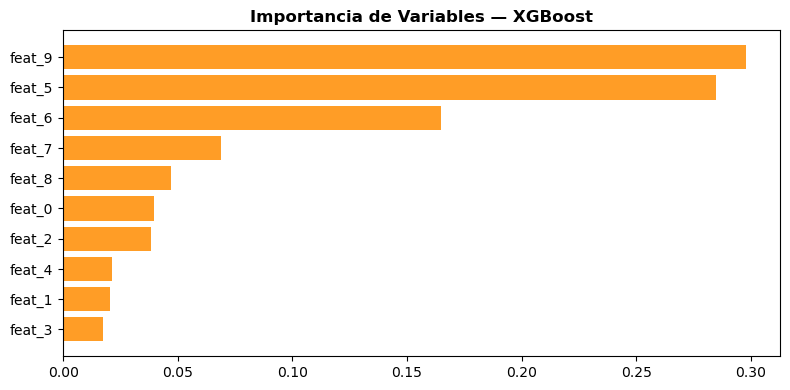

In [51]:
fi_xgb = xgb.get_feature_importance()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(fi_xgb['Feature'], fi_xgb['Importancia'], color='darkorange', alpha=0.85)
ax.set_title('Importancia de Variables — XGBoost', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 7. Modelo 5 — CatBoost Regression

Potente algoritmo de gradient boosting con soporte nativo para variables categóricas.
No requiere encoding previo ni escalado de features.

In [ ]:
# ── Uso mínimo ────────────────────────────────────────────────────────
cb = CatBoostRegression().fit(X_df, y_s)

In [ ]:
cb.print_metrics()

In [ ]:
fi_cb = cb.get_feature_importance()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(fi_cb['Feature'], fi_cb['Importancia'], color='mediumpurple', alpha=0.85)
ax.set_title('Importancia de Variables — CatBoost', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Con tuning automático (aumenta n_iter para mejor búsqueda)
cb_tuned = CatBoostRegression(tune=True, n_iter=10, cv=3).fit(X_df, y_s)
cb_tuned.print_metrics()

---
## 8. Comparación Final

In [ ]:
# Recopilar métricas de todos los modelos
resumen = pd.DataFrame([
    {'Modelo': 'Stepwise AIC',   **sw.get_metrics()},
    {'Modelo': 'Lasso',          **reg.get_metrics('lasso')},
    {'Modelo': 'Ridge',          **reg.get_metrics('ridge')},
    {'Modelo': 'Random Forest',  **rf.get_metrics()},
    {'Modelo': 'XGBoost',        **xgb.get_metrics()},
    {'Modelo': 'CatBoost',       **cb.get_metrics()},
]).set_index('Modelo')[['R²', 'MSE', 'RMSE', 'MAE']]

resumen

In [ ]:
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in [
    (axes[0], 'R²',   'R² en Test (↑ mejor)'),
    (axes[1], 'RMSE', 'RMSE en Test (↓ mejor)'),
]:
    bars = ax.bar(resumen.index, resumen[col], color=colors, alpha=0.9, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xticklabels(resumen.index, rotation=30, ha='right')
    for bar, val in zip(bars, resumen[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + resumen[col].max()*0.01,
                f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Comparación de Modelos', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Scatter Real vs Predicho para los 5 modelos base
modelos_base = [
    ('Stepwise AIC',  sw,  '#4C72B0', sw.X_test_,  sw.y_test_,
     lambda m, X: m.pipeline_.predict(X[:, [m.feature_names_.index(f) for f in m.selected_features_]])),
    ('Lasso',         reg, '#DD8452', reg.X_test_, reg.y_test_,
     lambda m, X: m.pipelines_['lasso'].predict(X)),
    ('Random Forest', rf,  '#55A868', rf.X_test_,  rf.y_test_,
     lambda m, X: m.pipeline_.predict(X)),
    ('XGBoost',       xgb, '#C44E52', xgb.X_test_, xgb.y_test_,
     lambda m, X: m.pipeline_.predict(X)),
    ('CatBoost',      cb,  '#8172B2', cb.X_test_,  cb.y_test_,
     lambda m, X: m.pipeline_.predict(X)),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, (title, model, color, Xte, yte, pred_fn) in zip(axes.flat, modelos_base):
    y_pred = pred_fn(model, Xte)
    ax.scatter(yte, y_pred, alpha=0.35, s=12, color=color)
    lims = [min(yte.min(), y_pred.min()), max(yte.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', lw=1.2)
    ax.set_xlabel('Real')
    ax.set_ylabel('Predicho')
    r2 = model.metrics_['R²'] if hasattr(model, 'metrics_') else model.get_metrics()['R²']
    ax.set_title(f'{title}  |  R² = {r2:.4f}', fontweight='bold')

axes.flat[-1].set_visible(False)   # ocultar el 6° subplot vacío

plt.suptitle('Real vs Predicho — Todos los Modelos',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 9. Resumen de la API

```python
# Todas las clases siguen la misma interfaz:

model = ClaseModelo().fit(X, y)       # una línea para todo el flujo
model.predict(X_nuevo)                # predicciones
model.print_metrics()                 # reporte en Test
model.get_metrics()                   # → dict con R², MSE, RMSE, MAE
model.summary()                       # → DataFrame de una fila

# Encadenamiento:
metrics = ClaseModelo().fit(X, y).get_metrics()

# Métodos extra por clase:
StepwiseLinearRegression:
  .print_aic_trace()      # historial del AIC paso a paso
  .get_aic_trace()        # → DataFrame
  .get_coefficients()     # → DataFrame con coeficientes

RegularizedRegression:
  .compare()              # → DataFrame Lasso vs Ridge
  .get_metrics('lasso')   # métricas de un método específico
  .get_coefficients()     # → DataFrame con ambos coeficientes

RandomForestRegression / XGBoostRegression / CatBoostRegression:
  .get_feature_importance()  # → DataFrame ordenado por importancia
  # tune=True activa RandomizedSearchCV automático

# CatBoostRegression — parámetros exclusivos:
CatBoostRegression(
    iterations=300,          # número de árboles
    depth=6,                 # profundidad máxima (hasta 16)
    l2_leaf_reg=3.0,         # regularización L2 en hojas
    random_strength=1.0,     # ruido anti-sobreajuste en splits
    cat_features=["col_a"],  # columnas categóricas (sin encoding previo)
)
```